In [30]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
    Created on Wed Jul 30 2025
    
    @author: Yaning
"""

import os
import torch
import pyro
from pyro.optim import Adam
import pyro.distributions as dist
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import seaborn as sns
import pickle
from pyro.infer import SVI, Trace_ELBO
import re
import pandas as pd

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [32]:
with open('/home/yaning/Documents/Discounting/results/array_cafe_gamble.pkl', 'rb') as f:
    data = pickle.load(f)

In [ ]:
# cafe and gamble group separation
group_1 = [1, 3, 4, 5, 6, 9, 14, 16, 17, 23, 30]
group_1 = [i - 1 for i in group_1]
group_2 = [2, 7, 8, 10, 11, 12, 13, 15, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29]
group_2 = [i - 1 for i in group_2]

In [ ]:
# future group separation
group_1 = [1,5,7,10,19,24,25,27,28,29]
group_1 = [i - 1 for i in group_1]
group_2 = [2, 3, 4, 6, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 26, 30]
group_2 = [i - 1 for i in group_2]

In [66]:
group_2 = []
for i in range(30):
    if i not in group_1:
        group_2.append(i+1)

In [34]:
data = data[:,group_2, :, :]

In [35]:
data = torch.tensor(data)

In [36]:
data.shape

torch.Size([2, 19, 170, 8])

In [37]:
data = data.reshape(data.shape[0]*data.shape[1],170,8)

In [38]:
data = data.to(device)

In [39]:
data.shape

torch.Size([38, 170, 8])

In [40]:
def model(data):
    num_params = 4
    num_agents = data.shape[0]
    num_trials = data.shape[1]
    # define hyper priors over model parameters
    # prior over sigma of a Gaussian is a Gamma distribution
    a = pyro.param('a', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    lam = pyro.param('lam', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    tau = pyro.sample('tau', dist.Gamma(a, a/lam).to_event(1)) # mean = a / (a/lam) = lam

    sig = pyro.deterministic('sig', 1/torch.sqrt(tau)) # Gauss sigma

    # each model parameter has a hyperprior defining group level mean
    # in the form of a Normal distribution
    m = pyro.param('m', torch.zeros(num_params, device=device))
    s = pyro.param('s', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    mu = pyro.sample('mu', dist.Normal(m, s*sig).to_event(1)) # Gauss mu, wieso s*sig?

    # in order to implement groups, where each subject is independent of the others, pyro uses so-called plates.
    # you embed what should be done for each subject into the "with pyro.plate" context
    # the plate vectorizes subjects and adds an additional dimension onto all arrays/tensors
    # i.e. p1 below will have the length num_agents
    with pyro.plate('ag_idx', num_agents):
        # draw parameters from Normal and transform (for numeric trick reasons)
        # base_dist = dist.Normal(0., 1.).expand_by([num_params]).to_event(1)
        base_dist = dist.Normal(torch.zeros(num_params, device=device), torch.ones(num_params, device=device)).to_event(1)
        # Transform via the pointwise affine mapping y = loc + scale*x (-> Neal's funnel)
        transform = dist.transforms.AffineTransform(mu, sig)

        locs = pyro.sample('locs', dist.TransformedDistribution(base_dist, [transform]))
        # print(locs.shape)


    with pyro.plate('data', num_agents*num_trials):
        sigma_rate = torch.exp(locs[:,0]).unsqueeze(-1).expand(-1, num_trials)
        exp_a = torch.exp(locs[:,1]).unsqueeze(-1).expand(-1, num_trials)
        exp_b = torch.exp(locs[:,2]).unsqueeze(-1).expand(-1, num_trials)
        beta = torch.exp(locs[:,3]).unsqueeze(-1).expand(-1, num_trials)

        sigma_combine = sigma_rate/(1+exp_b*torch.exp(-exp_a*data[:,:,2]))

        e_mean = (data[:,:,3])/(sigma_combine**2 + 1)
        sum = e_mean + torch.tensor(20., device=device)

        softmax_args = torch.stack([beta*e_mean/sum, beta*torch.tensor(20., device=device)/sum])
        p = torch.softmax(softmax_args, dim = 0)[0]

    pyro.sample("obs", dist.Bernoulli(probs = p).to_event(2), obs=data[:,:,4])

    # return locs

In [41]:
def guide(data):
    num_params = 4
    num_agents = data.shape[0]
    # biject_to(constraint) looks up a bijective Transform from constraints.real 
    # to the given constraint. The returned transform is guaranteed to have 
    # .bijective = True and should implement .log_abs_det_jacobian().
    trns = torch.distributions.biject_to(dist.constraints.positive)

    # define mean vector and covariance matrix of multivariate normal
    m_hyp = pyro.param('m_hyp', torch.zeros(2*num_params, device=data.device))
    st_hyp = pyro.param('scale_tril_hyp',
                    torch.eye(2*num_params, device=data.device),
                    constraint=dist.constraints.lower_cholesky)

    # set hyperprior to be multivariate normal
    # scale_tril (Tensor) – lower-triangular factor of covariance, with positive-valued diagonal
    hyp = pyro.sample('hyp',
                    dist.MultivariateNormal(m_hyp, scale_tril=st_hyp),
                    infer={'is_auxiliary': True})

    # mu & tau unconstrained
    unc_mu = hyp[..., :num_params]
    unc_tau = hyp[..., num_params:]

    # constrained tau, shape num_params, or num_particles, 1, num_params
    c_tau = trns(unc_tau)

    # ld = log_density
    # log_abs_det_jacobian(x, y) computes derivative |dy/dx|
    ld_tau = -trns.inv.log_abs_det_jacobian(c_tau, unc_tau)
    
    # sum_rightmost(x, dim)
    # sum out ``dim`` many rightmost dimensions of a given tensor.
    # ld_tau.shape is num_params, or num_particles, 1, num_params before sum_rightmost
    ld_tau = dist.util.sum_rightmost(ld_tau, ld_tau.dim() - c_tau.dim() + 1)

    # some numerics tricks
    mu = pyro.sample("mu", dist.Delta(unc_mu, event_dim=1))
    # c_tau shape: num_params, or num_particles, 1, num_params
    # ld_tau shape: [] or num_particles, 1,
    tau = pyro.sample("tau", dist.Delta(c_tau, log_density=ld_tau, event_dim=1))

    m_locs = pyro.param('m_locs', torch.zeros(num_agents, num_params, device=data.device))
    st_locs = pyro.param('scale_tril_locs',
                    torch.eye(num_params, device=data.device).repeat(num_agents, 1, 1),
                    constraint=dist.constraints.lower_cholesky)
    
    with pyro.plate('ag_idx', num_agents):
        locs = pyro.sample("locs", dist.MultivariateNormal(m_locs, scale_tril=st_locs))

    return {'tau': tau, 'mu': mu, 'locs': locs, 'm_locs': m_locs, 'st_locs': st_locs}

Mean ELBO 1220.41: 100%|█████████████████████████████████████████████████████████████████████████| 5000/5000 [01:08<00:00, 72.58it/s]


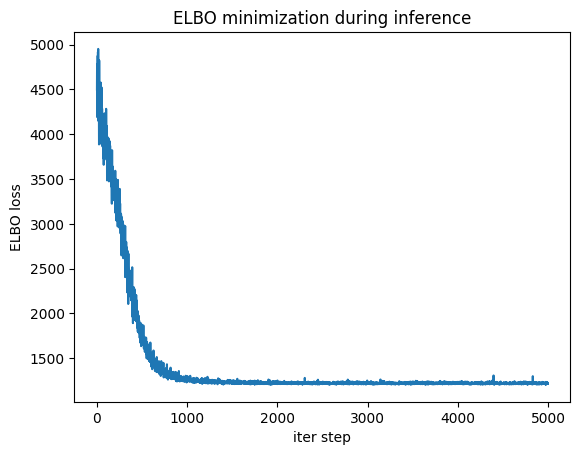

In [42]:
# this is for running the notebook in our testing framework
smoke_test = ('CI' in os.environ)
# the step was 2000
n_steps = 2 if smoke_test else 5000

# assert pyro.__version__.startswith('1.8.6')

# clear the param store in case we're in a REPL
pyro.clear_param_store()# setup the optimizer
# the learning rate was 0.0005 , "betas": (0.90, 0.999)
# tried "n_par":15 in adam params but it does not have this argument
adam_params = {"lr": 0.01}
optimizer = Adam(adam_params)
# setup the inference algorithm
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
# svi = SVI(model_gamma, guide_gamma, optimizer, loss=Trace_ELBO())

loss = []
pbar = tqdm(range(n_steps), position = 0)
# do gradient steps
for step in pbar:
    loss.append(torch.tensor(svi.step(data)))
    pbar.set_description("Mean ELBO %6.2f" % torch.tensor(loss[-20:]).mean())
    # for name, value in pyro.get_param_store().items():
    #     print(name, pyro.param(name))
    if torch.isnan(loss[-1]):
	    break

plt.figure()
plt.plot(loss)
plt.xlabel("iter step")
plt.ylabel("ELBO loss")
plt.title("ELBO minimization during inference")
plt.show()

In [44]:
for i in loss:
    print(i.numpy())

4499.621
4696.469
4619.0117
4575.3267
4190.4077
4472.455
4429.828
4787.238
4319.239
4876.8276
4451.553
4918.8145
4230.64
4428.315
4952.376
4362.256
4148.3027
4524.884
4631.6904
4437.9927
4342.2837
4470.3755
4258.652
3886.2815
3985.7034
4824.1743
4357.7544
4254.095
4396.3726
4225.2036
4154.8296
4156.856
4571.523
4202.5513
4389.578
4432.392
4229.5503
4304.2104
4301.2417
4173.0425
4165.8066
4323.863
3896.0198
4576.3228
4184.969
4161.369
4073.021
4496.7495
4273.56
3985.8113
4035.1338
4522.662
4060.4417
4098.826
4290.769
3984.8389
4068.7725
4285.4717
3917.242
4193.1704
4142.519
4102.43
3862.611
4109.7915
4026.1387
4054.1606
3954.0515
4136.156
3732.8196
4228.5747
4102.871
3810.6897
3996.4758
3740.2703
4174.731
3659.0132
3835.2786
4101.8555
4069.914
4130.3867
3957.5476
4011.5208
4089.6348
3865.8694
3986.0166
4192.726
4189.0244
4233.9453
3940.8252
4094.05
4120.2827
4033.9705
3970.8276
3987.8357
3916.6248
4046.3145
3950.9023
4133.8433
3941.3176
4160.9204
3728.9048
3769.5146
4283.566
3991.168
39

In [45]:
pos_dict = {}
for name, value in pyro.get_param_store().items():
    pos_dict[name] = value

# change the dictionary to numpy instead of tensor
# because somehow the tensor cannot be save with pickle
numpy_dict = {key: value.detach().cpu().numpy() for key, value in pos_dict.items()}

In [46]:
df_indiv = pd.DataFrame(numpy_dict["m_locs"], columns=['sigma_rate', 'exp_a', 'exp_b', 'beta'])

In [47]:
df_mean = pd.DataFrame(numpy_dict["m"].reshape(1,4), columns=['sigma_rate', 'exp_a', 'exp_b', 'beta'])

In [48]:
df_indiv.to_csv("/home/yaning/Documents/Discounting/paper/results/cafe_gamble_high_group_indiv.csv", index=False)

In [49]:
df_mean.to_csv("/home/yaning/Documents/Discounting/paper/results/cafe_gamble_high_group_mean.csv", index=False)

In [50]:
# save the dictionary
with open('/home/yaning/Documents/Discounting/paper/results/cafe_gamble_high_group.pkl', 'wb') as f:
    pickle.dump(numpy_dict, f)

Use guide to get the posterior (very important)

In [51]:
sample_num = 1000
tau = []
mu = []
locs = []
for i in range(sample_num):
    tau.append(guide(data)['tau'].detach().cpu().numpy())
    mu.append(guide(data)['mu'].detach().cpu().numpy())
    locs.append(guide(data)['locs'].detach().cpu().numpy())

In [52]:
tau = np.array(tau)
mu = np.array(mu)
locs = np.array(locs)

In [53]:
sample_dict = {}
sample_dict['tau'] = tau
sample_dict['mu'] = mu
sample_dict['locs'] = locs

In [54]:
# save the dictionary
with open('/home/yaning/Documents/Discounting/paper/results/cafe_gamble_high_group_samples.pkl', 'wb') as f:
    pickle.dump(sample_dict, f)

In [55]:
df = pd.DataFrame(mu, columns=['sigma_rate', 'exp_a', 'exp_b', 'beta'])

In [56]:
df.to_csv("/home/yaning/Documents/Discounting/paper/results/cafe_gamble_high_group_samples.csv", index=False)